# Independent catalogue validation with InfraPy Bartlett beamforming

This notebook uses the standard frequency-domain Bartlett beamformer in
**LANL InfraPy** to provide an implementation-independent check of the Falcon 9
infrasound catalogue and of the direction and trace-velocity estimates obtained
elsewhere in the workflow.

The notebook answers two distinct questions:

1. **Event-centred validation:** when a window is centred on each of the 153
   manually associated transients, does InfraPy recover coherent energy from
   the direction of SLC-40 at a physically plausible trace velocity?
2. **Blind continuous validation:** when the waveform is scanned without using
   catalogue times, which local coherence peaks match catalogue entries and
   are any physically consistent unmatched peaks retained for review?

Event-centred analysis validates direction, trace velocity, and coherence, but
is not an independent test of event count. The blind scan provides a separate
completeness diagnostic; its overlapping-window maxima are not interpreted as
individual explosions.

Official resources:

- <https://github.com/LANL-Seismoacoustics/infrapy>
- <https://infrapy.readthedocs.io/en/latest/beamforming.html>
- <https://infrapy.readthedocs.io/en/latest/algorithms.html>

## Important implementation choices

- The ObsPy `Stream` is passed directly to InfraPy; no intermediate waveform
  export is required.
- Channel codes, coordinates, and the expected source direction are read from
  Notebook 010 products rather than hard-coded.
- The meteorological velocity reference is read from the Notebook 020 acoustic
  summary and rounded to the justified precision for display.
- InfraPy's lower-level Bartlett API is used so that beam-window centre times
  retain sub-second precision.
- The primary analysis uses all three pressure sensors. Two sensors cannot
  independently resolve both back azimuth and trace velocity.
- Trace velocity need not equal thermodynamic sound speed. The meteorological
  value is an external reference rather than a Bartlett constraint.

In [2]:
from __future__ import annotations

import importlib.metadata
import json
import platform
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from obspy import UTCDateTime, read
from scipy.signal import find_peaks

project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from modules import project_config as config

pd.set_option("display.max_columns", 100)
plt.rcParams.update({"figure.dpi": 120, "axes.grid": True})

print("Data directory:", config.DATA_DIR)

Data directory: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data


## InfraPy installation and provenance

InfraPy is intentionally not installed by this notebook. The official project
currently recommends cloning the LANL repository and creating its supplied
Conda environment:

```bash
git clone https://github.com/LANL-Seismoacoustics/infrapy.git
cd infrapy
conda env create -f infrapy_env.yml
conda activate infrapy_env
```

Register that environment as a Jupyter kernel if needed. Installing only the
top-level package into the existing analysis environment can omit dependencies
such as Pisces, so the official environment file is the safer reproducible
route.

In [3]:
try:
    import infrapy
    from infrapy.detection import beamforming_new as infrapy_bf
except ImportError as exc:
    raise ImportError(
        "InfraPy is unavailable in this kernel. Install it from the official "
        "LANL repository using infrapy_env.yml, activate that environment, "
        "and restart the notebook with its Jupyter kernel."
    ) from exc

try:
    INFRAPY_VERSION = importlib.metadata.version("infrapy")
except importlib.metadata.PackageNotFoundError:
    INFRAPY_VERSION = "source checkout / version unavailable"

INFRAPY_MODULE_FILE = Path(infrapy.__file__).resolve()
print("InfraPy version:", INFRAPY_VERSION)
print("InfraPy module:", INFRAPY_MODULE_FILE)

InfraPy version: 0.4.1.0
InfraPy module: /Users/thompsong/Developer/infrapy/infrapy/__init__.py


## 1. Inputs and channel/geometry reconciliation

In [4]:
ANALYSIS_CONFIG_FILE = config.NB010_DIR / "analysis_configuration.json"
FINAL_CATALOGUE_FILE = config.NB030_DIR / "final_153_event_catalogue.csv"
WEATHER_ACOUSTIC_SUMMARY_FILE = (
    config.NB020_DIR / "weather_acoustic_summary.csv"
)
OUTPUT_DIRECTORY = config.NB040_DIR
FIGURE_DIRECTORY = config.NB040_DIR / "figures"

for required in (
    ANALYSIS_CONFIG_FILE,
    FINAL_CATALOGUE_FILE,
    WEATHER_ACOUSTIC_SUMMARY_FILE,
):
    if not required.exists():
        raise FileNotFoundError(required)

analysis_config = json.loads(ANALYSIS_CONFIG_FILE.read_text())
geometry_file = Path(analysis_config["geometry_file"]).expanduser()
if not geometry_file.exists():
    fallback = config.NB010_DIR / "02_bchh_geometry.csv"
    if not fallback.exists():
        raise FileNotFoundError(geometry_file)
    geometry_file = fallback

catalogue = pd.read_csv(FINAL_CATALOGUE_FILE)
geometry = pd.read_csv(geometry_file)

baseline_products = analysis_config.get("baseline_removed_streams", {})
BASELINE_MSEED_FILE = Path(
    baseline_products.get(
        "mseed",
        config.NB010_DIR
        / "bchh_corrected_moving_median_baseline_removed.mseed",
    )
).expanduser()
BASELINE_PICKLE_FILE = Path(
    baseline_products.get(
        "pickle",
        config.NB010_DIR
        / "bchh_corrected_moving_median_baseline_removed.pkl",
    )
).expanduser()

# MiniSEED is preferred because Notebook 040 may run in a separate InfraPy
# Python environment. Python pickle is not a stable cross-version interchange
# format.
if BASELINE_MSEED_FILE.exists():
    BASELINE_STREAM_FILE = BASELINE_MSEED_FILE
    full_stream = read(str(BASELINE_STREAM_FILE), format="MSEED")
elif BASELINE_PICKLE_FILE.exists():
    BASELINE_STREAM_FILE = BASELINE_PICKLE_FILE
    try:
        full_stream = read(str(BASELINE_STREAM_FILE), format="PICKLE")
    except Exception as exc:
        raise RuntimeError(
            "The Notebook 02 baseline PICKLE is incompatible with this "
            "Python/ObsPy environment. Re-run Notebook 02 to write the "
            f"portable MiniSEED product: {BASELINE_MSEED_FILE}"
        ) from exc
else:
    raise FileNotFoundError(
        "Notebook 02 baseline-corrected Stream not found. "
        f"Expected {BASELINE_MSEED_FILE} or {BASELINE_PICKLE_FILE}"
    )

stream_channels = [tr.stats.channel for tr in full_stream]
configured_pressure_channels = analysis_config.get("pressure_channels", [])
pressure_channels = [
    channel
    for channel in configured_pressure_channels
    if channel in stream_channels
]
if not pressure_channels:
    pressure_channels = [
        tr.stats.channel
        for tr in full_stream
        if str(getattr(tr.stats, "units", "")).lower()
        in {"pa", "pascal", "pascals"}
    ]
pressure_channels = list(dict.fromkeys(pressure_channels))

if len(pressure_channels) != 3:
    raise ValueError(
        "Bartlett validation expects exactly three pressure channels; found "
        f"{pressure_channels}."
    )

pressure_stream = full_stream.__class__()
for channel in pressure_channels:
    matches = full_stream.select(channel=channel)
    if len(matches) != 1:
        raise ValueError(
            f"Expected one trace for {channel}; found {len(matches)}"
        )
    pressure_stream += matches[0].copy()

pressure_geometry = (
    geometry.set_index("channel")
    .loc[pressure_channels]
    .reset_index()
)
latlon = pressure_geometry[["latitude", "longitude"]].to_numpy(float)

sampling_rates = {float(tr.stats.sampling_rate) for tr in pressure_stream}
if len(sampling_rates) != 1:
    raise ValueError(
        f"Pressure traces have mixed sample rates: {sampling_rates}"
    )
sampling_rate_hz = sampling_rates.pop()

print("Baseline-corrected Stream from Notebook 02:", BASELINE_STREAM_FILE)
print("Pressure channels:", pressure_channels)
print("Sampling rate:", sampling_rate_hz)

Baseline-corrected Stream from Notebook 02: /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/010_prepare_analysis_inputs/bchh_corrected_moving_median_baseline_removed.mseed
Pressure channels: ['DD1', 'DD2', 'DD3']
Sampling rate: 250.0


In [5]:
# Verify that InfraPy constructs geometry consistent with the surveyed array.
x_all, t_all, t0_all, infrapy_geometry_m = infrapy_bf.stream_to_array_data(
    pressure_stream,
    latlon=latlon,
)

geometry_check = pressure_geometry[["channel", "latitude", "longitude"]].copy()
geometry_check["infrapy_east_offset_m"] = infrapy_geometry_m[:, 0]
geometry_check["infrapy_north_offset_m"] = infrapy_geometry_m[:, 1]
display(geometry_check)

if not np.all(np.isfinite(x_all)):
    raise ValueError("The common pressure array contains non-finite samples.")

,channel,latitude,longitude,infrapy_east_offset_m,infrapy_north_offset_m
0,DD1,28.574222,-80.572417,0.000000,-0.000000
1,DD2,28.573881,-80.572296,11.823639,-37.852953
2,DD3,28.574006,-80.572560,-14.021757,-23.925793


## 2. Analysis controls

`RUN_MODE` determines whether the optional blind scan is performed:

- `"event_validation"`: analyse the catalogue and matched pre-event background
  only.
- `"continuous_smoke"`: add a short blind scan for installation testing.
- `"continuous_full"`: add the full blind scan through the final catalogue
  event. This production setting generates all publication and supplementary
  products in one run.

The primary 0.5-s window has 2-Hz Fourier-bin spacing. The adopted 2--20 Hz
band is therefore a practical compromise for the short transients. Adjacent
window/band choices are tested below rather than selecting the primary setting
solely for agreement with the manual catalogue.

In [6]:
RUN_MODE = "continuous_full"  # event_validation | continuous_smoke | continuous_full
METHOD = "bartlett"
FREQ_MIN_HZ = 2.0
FREQ_MAX_HZ = 20.0
WINDOW_LENGTH_S = 0.50
WINDOW_STEP_S = 0.10

BACK_AZIMUTH_VALUES_DEG = np.arange(170.0, 230.0 + 0.5, 0.5)
TRACE_VELOCITY_VALUES_MPS = np.arange(280.0, 440.0 + 2.0, 2.0)

# The blind scan evaluates many more windows, so it uses a coarser screening
# grid. Event-centred estimates retain the fine grid above.
CONTINUOUS_BACK_AZIMUTH_VALUES_DEG = np.arange(170.0, 230.0 + 1.0, 1.0)
CONTINUOUS_TRACE_VELOCITY_VALUES_MPS = np.arange(280.0, 440.0 + 5.0, 5.0)

MIN_DETECTION_WINDOWS = 2
MAX_BACK_AZIMUTH_STD_95_DEG = 15.0
BACKGROUND_F_QUANTILE = 0.995
MATCH_TOLERANCE_S = max(WINDOW_LENGTH_S / 2.0, WINDOW_STEP_S)
BLIND_PEAK_MINIMUM_SEPARATION_S = 0.10
BLIND_PEAK_MINIMUM_PROMINENCE_MAD = 2.0

# Used only to prioritize unmatched peaks for manual review, not to define the
# catalogue or count explosions.
PRIORITY_BACK_AZIMUTH_TOLERANCE_DEG = 10.0
PRIORITY_TRACE_VELOCITY_RANGE_MPS = (300.0, 400.0)

SMOKE_PRE_EVENT_S = 2.0
SMOKE_DURATION_S = 20.0

# A full scan is computationally expensive. Change this to False when using
# event_validation or continuous_smoke during development.
CONFIRM_FULL_CONTINUOUS_RUN = True

EXPECTED_BACK_AZIMUTH_DEG = float(
    analysis_config["array_reference"]["back_azimuth_to_slc40_deg"]
)
weather_acoustic_summary = pd.read_csv(WEATHER_ACOUSTIC_SUMMARY_FILE).iloc[0]
METEOROLOGICAL_EFFECTIVE_SPEED_MPS = float(
    weather_acoustic_summary["effective_sound_speed_mps"]
)
METEOROLOGICAL_EFFECTIVE_SPEED_DISPLAY_MPS = round(
    METEOROLOGICAL_EFFECTIVE_SPEED_MPS, 1
)

fft_bin_spacing_hz = 1.0 / WINDOW_LENGTH_S
frequency_bin_count = int(
    np.floor(FREQ_MAX_HZ / fft_bin_spacing_hz)
    - np.ceil(FREQ_MIN_HZ / fft_bin_spacing_hz)
    + 1
)
grid_size = len(BACK_AZIMUTH_VALUES_DEG) * len(TRACE_VELOCITY_VALUES_MPS)
continuous_grid_size = (
    len(CONTINUOUS_BACK_AZIMUTH_VALUES_DEG)
    * len(CONTINUOUS_TRACE_VELOCITY_VALUES_MPS)
)

print(f"FFT-bin spacing: {fft_bin_spacing_hz:.2f} Hz")
print(f"Approximate in-band bins: {frequency_bin_count}")
print(f"Steering models per event window: {grid_size:,}")
print(f"Continuous-screening models per window: {continuous_grid_size:,}")
print(f"Expected SLC-40 back azimuth: {EXPECTED_BACK_AZIMUTH_DEG:.2f}°")
print(
    "Meteorological effective-speed reference: "
    f"{METEOROLOGICAL_EFFECTIVE_SPEED_DISPLAY_MPS:.1f} m/s"
)

FFT-bin spacing: 2.00 Hz
Approximate in-band bins: 10
Steering models per event window: 9,801
Continuous-screening models per window: 2,013
Expected SLC-40 back azimuth: 199.44°
Meteorological effective-speed reference: 351.0 m/s


## 3. InfraPy Bartlett wrapper with sub-second timing

In [7]:
def circular_difference_deg(values, reference):
    # Signed smallest angular difference, values minus reference.
    values = np.asarray(values, dtype=float)
    return (values - float(reference) + 180.0) % 360.0 - 180.0


def beamform_windows(
    stream,
    latlon_values,
    window_centres_epoch_s,
    *,
    window_length_s,
    freq_band_hz,
    back_azimuth_values_deg,
    trace_velocity_values_mps,
    label,
):
    # Run InfraPy Bartlett beamforming at specified absolute window centres.
    x, t, t0, array_geometry_m = infrapy_bf.stream_to_array_data(
        stream,
        latlon=np.asarray(latlon_values, dtype=float),
    )
    trace_count = x.shape[0]
    t0_epoch_s = pd.Timestamp(t0).timestamp()

    slowness = infrapy_bf.build_slowness(
        np.asarray(back_azimuth_values_deg, dtype=float),
        np.asarray(trace_velocity_values_mps, dtype=float),
    )
    delays = infrapy_bf.compute_delays(array_geometry_m, slowness)

    stream_start_epoch_s = t0_epoch_s + float(t[0])
    stream_end_epoch_s = t0_epoch_s + float(t[-1])
    half_window_s = window_length_s / 2.0
    records = []
    started = time.perf_counter()

    centres = np.asarray(window_centres_epoch_s, dtype=float)
    for index, centre_epoch_s in enumerate(centres, start=1):
        start_epoch_s = centre_epoch_s - half_window_s
        end_epoch_s = centre_epoch_s + half_window_s
        if start_epoch_s < stream_start_epoch_s or end_epoch_s > stream_end_epoch_s:
            continue

        relative_window = [
            start_epoch_s - t0_epoch_s,
            end_epoch_s - t0_epoch_s,
        ]
        X, S, frequencies_hz = infrapy_bf.fft_array_data(
            x,
            t,
            window=relative_window,
        )
        beam_power = infrapy_bf.run(
            X,
            S,
            frequencies_hz,
            array_geometry_m,
            delays,
            list(freq_band_hz),
            method="bartlett",
            pool=None,
            normalize_beam=True,
            ns_covar_inv=None,
        )
        peak = infrapy_bf.find_peaks(
            beam_power,
            np.asarray(back_azimuth_values_deg, dtype=float),
            np.asarray(trace_velocity_values_mps, dtype=float),
            signal_cnt=1,
        )[0]
        coherence = float(np.clip(peak[2], 0.0, 1.0 - np.finfo(float).eps))
        f_stat = coherence / (1.0 - coherence) * (trace_count - 1)

        records.append(
            {
                "analysis_label": label,
                "beam_centre_epoch_s": centre_epoch_s,
                "beam_centre_time": str(UTCDateTime(centre_epoch_s)),
                "back_azimuth_deg": float(peak[0]),
                "trace_velocity_mps": float(peak[1]),
                "bartlett_coherence": coherence,
                "f_stat": float(f_stat),
                "back_azimuth_grid_edge": bool(
                    peak[0]
                    <= back_azimuth_values_deg[0]
                    + np.diff(back_azimuth_values_deg).min() / 2.0
                    or peak[0]
                    >= back_azimuth_values_deg[-1]
                    - np.diff(back_azimuth_values_deg).min() / 2.0
                ),
                "trace_velocity_grid_edge": bool(
                    peak[1]
                    <= trace_velocity_values_mps[0]
                    + np.diff(trace_velocity_values_mps).min() / 2.0
                    or peak[1]
                    >= trace_velocity_values_mps[-1]
                    - np.diff(trace_velocity_values_mps).min() / 2.0
                ),
            }
        )
        if index == 1 or index % 100 == 0 or index == len(centres):
            elapsed = time.perf_counter() - started
            print(f"{label}: {index:,}/{len(centres):,} windows; {elapsed:.1f} s")

    result = pd.DataFrame.from_records(records)
    if result.empty:
        raise RuntimeError(f"No valid windows were analyzed for {label}.")
    result["back_azimuth_error_deg"] = circular_difference_deg(
        result["back_azimuth_deg"], EXPECTED_BACK_AZIMUTH_DEG
    )
    result["trace_velocity_minus_meteorology_mps"] = (
        result["trace_velocity_mps"] - METEOROLOGICAL_EFFECTIVE_SPEED_MPS
    )
    return result

## 4. Define event, background, and continuous windows

In [8]:
event_centres_epoch_s = catalogue["reduced_event_epoch_s"].to_numpy(float)
first_event_epoch_s = float(event_centres_epoch_s.min())
last_event_epoch_s = float(event_centres_epoch_s.max())

common_start_epoch_s = max(
    float(tr.stats.starttime.timestamp) for tr in pressure_stream
)
common_end_epoch_s = min(
    float(tr.stats.endtime.timestamp) for tr in pressure_stream
)

# Use evenly spaced, non-overlapping pre-event windows as an independent null sample.
background_end_epoch_s = first_event_epoch_s - WINDOW_LENGTH_S
background_centres_epoch_s = np.linspace(
    common_start_epoch_s + WINDOW_LENGTH_S / 2.0,
    background_end_epoch_s - WINDOW_LENGTH_S / 2.0,
    num=len(catalogue),
)

if RUN_MODE == "event_validation":
    selected_continuous_centres = np.array([], dtype=float)
elif RUN_MODE == "continuous_smoke":
    scan_start = first_event_epoch_s - SMOKE_PRE_EVENT_S
    scan_end = scan_start + SMOKE_DURATION_S
    selected_continuous_centres = np.arange(
        scan_start + WINDOW_LENGTH_S / 2.0,
        scan_end - WINDOW_LENGTH_S / 2.0 + WINDOW_STEP_S / 2.0,
        WINDOW_STEP_S,
    )
elif RUN_MODE == "continuous_full":
    if not CONFIRM_FULL_CONTINUOUS_RUN:
        raise RuntimeError(
            "Set CONFIRM_FULL_CONTINUOUS_RUN=True after reviewing the estimated "
            "window count and runtime."
        )
    scan_start = common_start_epoch_s
    scan_end = min(common_end_epoch_s, last_event_epoch_s + 2.0)
    selected_continuous_centres = np.arange(
        scan_start + WINDOW_LENGTH_S / 2.0,
        scan_end - WINDOW_LENGTH_S / 2.0 + WINDOW_STEP_S / 2.0,
        WINDOW_STEP_S,
    )
else:
    raise ValueError(f"Unknown RUN_MODE: {RUN_MODE}")

print("Event-centred windows:", len(event_centres_epoch_s))
print("Background windows:", len(background_centres_epoch_s))
print("Continuous windows:", len(selected_continuous_centres))
if len(selected_continuous_centres):
    print(
        "Continuous steering evaluations:",
        f"{len(selected_continuous_centres) * continuous_grid_size:,}",
    )

Event-centred windows: 153
Background windows: 153
Continuous windows: 17839
Continuous steering evaluations: 35,909,907


## 5. Independent waveform-quality measurements

A consistent waveform-quality set is calculated directly from the Notebook 010
baseline-corrected pressure stream for all 153 entries:

- traces are aligned using surveyed source--receiver distances and the
  meteorological effective speed, independently of the Bartlett solution;
- peak SNR is the maximum absolute median-stack signal divided by a robust
  pre-event MAD noise estimate;
- RMS SNR is the median-stack signal RMS divided by its pre-event noise RMS;
- pair correlation is the maximum normalized correlation within a small
  residual-lag search after fixed-geometry alignment.

The correlation pair is selected automatically as the configured reference
sensor and its closest-range pressure companion, giving DD2--DD3 for BCHH.
Local noise windows can contain earlier events during dense phases, so
neighbouring-event gaps and an isolation flag are also retained.

In [9]:
QUALITY_SIGNAL_WINDOW_S = (-0.08, 0.25)
QUALITY_NOISE_WINDOW_S = (-0.50, -0.15)
QUALITY_MAX_RESIDUAL_LAG_S = 0.020

reference_channel = analysis_config["infrasound_reference_channel"]
reference_distance_m = float(
    pressure_geometry.set_index("channel").loc[reference_channel, "distance_m"]
)
fixed_geometry_delays_s = {
    row.channel: (
        float(row.distance_m) - reference_distance_m
    ) / METEOROLOGICAL_EFFECTIVE_SPEED_MPS
    for row in pressure_geometry.itertuples()
}

pair_candidates = pressure_geometry.loc[
    pressure_geometry["channel"].ne(reference_channel)
].copy()
pair_candidates["absolute_range_difference_m"] = (
    pair_candidates["distance_m"] - reference_distance_m
).abs()
quality_pair = [
    reference_channel,
    str(pair_candidates.sort_values("absolute_range_difference_m").iloc[0]["channel"]),
]


def robust_scale(values):
    values = np.asarray(values, dtype=float)
    centre = np.nanmedian(values)
    scale = 1.4826 * np.nanmedian(np.abs(values - centre))
    if not np.isfinite(scale) or scale <= 0.0:
        scale = np.nanstd(values)
    return float(scale)


def sample_trace_at_epochs(trace, epoch_times):
    sample_indices = (
        np.asarray(epoch_times, dtype=float)
        - float(trace.stats.starttime.timestamp)
    ) * float(trace.stats.sampling_rate)
    return np.interp(
        sample_indices,
        np.arange(trace.stats.npts, dtype=float),
        np.asarray(trace.data, dtype=float),
        left=np.nan,
        right=np.nan,
    )


def maximum_normalized_correlation(first, second, maximum_lag_samples):
    first = np.asarray(first, dtype=float)
    second = np.asarray(second, dtype=float)
    records = []
    for lag in range(-maximum_lag_samples, maximum_lag_samples + 1):
        if lag < 0:
            x, y = first[-lag:], second[:lag]
        elif lag > 0:
            x, y = first[:-lag], second[lag:]
        else:
            x, y = first, second
        finite = np.isfinite(x) & np.isfinite(y)
        x, y = x[finite], y[finite]
        if len(x) < 3:
            continue
        x, y = x - np.mean(x), y - np.mean(y)
        denominator = np.linalg.norm(x) * np.linalg.norm(y)
        correlation = np.dot(x, y) / denominator if denominator > 0.0 else np.nan
        records.append((float(correlation), lag))
    finite_records = [record for record in records if np.isfinite(record[0])]
    if not finite_records:
        return np.nan, np.nan
    correlation, lag = max(finite_records, key=lambda record: record[0])
    return correlation, lag / sampling_rate_hz


trace_by_channel = {
    trace.stats.channel: trace
    for trace in pressure_stream
}
sample_interval_s = 1.0 / sampling_rate_hz
signal_relative_s = np.arange(
    QUALITY_SIGNAL_WINDOW_S[0],
    QUALITY_SIGNAL_WINDOW_S[1],
    sample_interval_s,
)
noise_relative_s = np.arange(
    QUALITY_NOISE_WINDOW_S[0],
    QUALITY_NOISE_WINDOW_S[1],
    sample_interval_s,
)
maximum_lag_samples = int(round(QUALITY_MAX_RESIDUAL_LAG_S * sampling_rate_hz))

quality_records = []
for event_number, event_epoch_s in zip(
    catalogue["final_event_number"].astype(int),
    event_centres_epoch_s,
):
    aligned_signal = {}
    aligned_noise = {}
    for channel in pressure_channels:
        delay_s = fixed_geometry_delays_s[channel]
        aligned_signal[channel] = sample_trace_at_epochs(
            trace_by_channel[channel],
            event_epoch_s + signal_relative_s + delay_s,
        )
        aligned_noise[channel] = sample_trace_at_epochs(
            trace_by_channel[channel],
            event_epoch_s + noise_relative_s + delay_s,
        )

    signal_stack = np.nanmedian(
        np.vstack([aligned_signal[channel] for channel in pressure_channels]),
        axis=0,
    )
    noise_stack = np.nanmedian(
        np.vstack([aligned_noise[channel] for channel in pressure_channels]),
        axis=0,
    )
    baseline = np.nanmedian(noise_stack)
    signal_stack = signal_stack - baseline
    noise_stack = noise_stack - baseline
    noise_robust_scale = robust_scale(noise_stack)
    noise_rms = float(np.sqrt(np.nanmean(noise_stack**2)))
    signal_rms = float(np.sqrt(np.nanmean(signal_stack**2)))

    pair_correlation, pair_residual_lag_s = maximum_normalized_correlation(
        aligned_signal[quality_pair[0]],
        aligned_signal[quality_pair[1]],
        maximum_lag_samples,
    )
    quality_records.append(
        {
            "final_event_number": event_number,
            "waveform_robust_stack_peak_snr": (
                float(np.nanmax(np.abs(signal_stack))) / noise_robust_scale
                if noise_robust_scale > 0.0 else np.nan
            ),
            "waveform_stack_signal_rms_pa": signal_rms,
            "waveform_stack_noise_rms_pa": noise_rms,
            "waveform_stack_rms_snr": signal_rms / noise_rms if noise_rms > 0.0 else np.nan,
            "waveform_pair_channels": "–".join(quality_pair),
            "waveform_pair_best_correlation": pair_correlation,
            "waveform_pair_residual_lag_s": pair_residual_lag_s,
        }
    )

waveform_quality = pd.DataFrame(quality_records)

# Preserve the earlier column schema for downstream Notebooks 050 and 060.
# New figures use descriptive names; these aliases are compatibility-only.
legacy_quality_aliases = {
    "s03_robust_stack_peak_snr": "waveform_robust_stack_peak_snr",
    "s03_stack_signal_rms_pa": "waveform_stack_signal_rms_pa",
    "s03_stack_noise_rms_pa": "waveform_stack_noise_rms_pa",
    "s03_stack_rms_snr": "waveform_stack_rms_snr",
    "s03_pair_channels": "waveform_pair_channels",
    "s03_pair_best_correlation": "waveform_pair_best_correlation",
    "s03_pair_residual_lag_s": "waveform_pair_residual_lag_s",
}
for legacy_name, current_name in legacy_quality_aliases.items():
    waveform_quality[legacy_name] = waveform_quality[current_name]

sorted_times = np.sort(event_centres_epoch_s)
previous_gaps = np.r_[np.inf, np.diff(sorted_times)]
next_gaps = np.r_[np.diff(sorted_times), np.inf]
gap_table = pd.DataFrame(
    {
        "reduced_event_epoch_s": sorted_times,
        "previous_event_gap_s": previous_gaps,
        "next_event_gap_s": next_gaps,
    }
)
gap_table["waveform_quality_window_isolated"] = (
    gap_table["previous_event_gap_s"] >= abs(QUALITY_NOISE_WINDOW_S[0])
) & (
    gap_table["next_event_gap_s"] >= QUALITY_SIGNAL_WINDOW_S[1]
)

print("Quality correlation pair:", "–".join(quality_pair))
display(waveform_quality.describe())

Quality correlation pair: DD2–DD3


,final_event_number,waveform_robust_stack_peak_snr,waveform_stack_signal_rms_pa,waveform_stack_noise_rms_pa,waveform_stack_rms_snr,waveform_pair_best_correlation,waveform_pair_residual_lag_s,s03_robust_stack_peak_snr,s03_stack_signal_rms_pa,s03_stack_noise_rms_pa,s03_stack_rms_snr,s03_pair_best_correlation,s03_pair_residual_lag_s
count,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000
mean,77.000000,14.328409,18.492424,4.406956,3.667397,0.805211,-0.001673,14.328409,18.492424,4.406956,3.667397,0.805211,-0.001673
std,44.311398,17.111567,61.540973,8.756726,3.621374,0.187396,0.002322,17.111567,61.540973,8.756726,3.621374,0.187396,0.002322
min,1.000000,2.037288,1.249593,0.927145,0.522821,0.214737,-0.008000,2.037288,1.249593,0.927145,0.522821,0.214737,-0.008000
25%,39.000000,5.494876,3.155069,1.386644,1.651533,0.718361,-0.004000,5.494876,3.155069,1.386644,1.651533,0.718361,-0.004000
50%,77.000000,7.859930,5.491458,1.904912,2.231592,0.875550,0.000000,7.859930,5.491458,1.904912,2.231592,0.875550,0.000000
75%,115.000000,16.104541,10.025948,3.268217,4.551085,0.954580,0.000000,16.104541,10.025948,3.268217,4.551085,0.954580,0.000000
max,153.000000,118.527264,447.635631,73.604255,19.608956,0.995207,0.012000,118.527264,447.635631,73.604255,19.608956,0.995207,0.012000


## 6. Run event-centred and background validation

In [10]:
event_beams = beamform_windows(
    pressure_stream,
    latlon,
    event_centres_epoch_s,
    window_length_s=WINDOW_LENGTH_S,
    freq_band_hz=(FREQ_MIN_HZ, FREQ_MAX_HZ),
    back_azimuth_values_deg=BACK_AZIMUTH_VALUES_DEG,
    trace_velocity_values_mps=TRACE_VELOCITY_VALUES_MPS,
    label="catalogue_event",
)
background_beams = beamform_windows(
    pressure_stream,
    latlon,
    background_centres_epoch_s,
    window_length_s=WINDOW_LENGTH_S,
    freq_band_hz=(FREQ_MIN_HZ, FREQ_MAX_HZ),
    back_azimuth_values_deg=BACK_AZIMUTH_VALUES_DEG,
    trace_velocity_values_mps=TRACE_VELOCITY_VALUES_MPS,
    label="pre_event_background",
)

empirical_f_threshold = float(
    background_beams["f_stat"].quantile(BACKGROUND_F_QUANTILE)
)

event_validation = catalogue.merge(
    event_beams,
    left_on="reduced_event_epoch_s",
    right_on="beam_centre_epoch_s",
    how="left",
    validate="one_to_one",
)
event_validation = (
    event_validation
    .merge(
        waveform_quality,
        on="final_event_number",
        how="left",
        validate="one_to_one",
    )
    .merge(
        gap_table,
        on="reduced_event_epoch_s",
        how="left",
        validate="one_to_one",
    )
)
event_validation["above_empirical_background_threshold"] = (
    event_validation["f_stat"] >= empirical_f_threshold
)
event_validation["direction_within_5_deg"] = (
    event_validation["back_azimuth_error_deg"].abs() <= 5.0
)
event_validation["direction_within_10_deg"] = (
    event_validation["back_azimuth_error_deg"].abs() <= 10.0
)
event_validation["f_quality_tier"] = pd.cut(
    event_validation["f_stat"],
    bins=[-np.inf, empirical_f_threshold, 5.0, 10.0, np.inf],
    labels=["below_background", "above_background", "F_ge_5", "F_ge_10"],
    right=False,
)

summary = pd.Series(
    {
        "catalogue_events": len(event_validation),
        "background_f_quantile": BACKGROUND_F_QUANTILE,
        "empirical_f_threshold": empirical_f_threshold,
        "events_above_threshold": int(
            event_validation["above_empirical_background_threshold"].sum()
        ),
        "events_within_5_deg": int(event_validation["direction_within_5_deg"].sum()),
        "events_within_10_deg": int(event_validation["direction_within_10_deg"].sum()),
        "median_back_azimuth_deg": event_validation["back_azimuth_deg"].median(),
        "median_trace_velocity_mps": event_validation["trace_velocity_mps"].median(),
        "median_f_stat": event_validation["f_stat"].median(),
        "back_azimuth_edge_hits": int(event_validation["back_azimuth_grid_edge"].sum()),
        "trace_velocity_edge_hits": int(event_validation["trace_velocity_grid_edge"].sum()),
    },
    name="value",
)
display(summary.to_frame())
display(
    event_validation[
        [
            "final_event_number",
            "reduced_event_time",
            "waveform_robust_stack_peak_snr",
            "waveform_stack_rms_snr",
            "waveform_pair_best_correlation",
            "back_azimuth_deg",
            "back_azimuth_error_deg",
            "trace_velocity_mps",
            "f_stat",
            "above_empirical_background_threshold",
        ]
    ].head(20)
)


def summarize_speed_tier(label, mask):
    selected = event_validation.loc[mask].copy()
    speed = selected["trace_velocity_mps"]
    return {
        "selection": label,
        "event_count": len(selected),
        "median_speed_mps": speed.median(),
        "speed_standard_deviation_mps": speed.std(),
        "speed_p05_mps": speed.quantile(0.05),
        "speed_p95_mps": speed.quantile(0.95),
        "median_abs_back_azimuth_error_deg": selected[
            "back_azimuth_error_deg"
        ].abs().median(),
        "speed_grid_edge_hits": int(selected["trace_velocity_grid_edge"].sum()),
    }


speed_quality_summary = pd.DataFrame(
    [
        summarize_speed_tier("all", np.ones(len(event_validation), dtype=bool)),
        summarize_speed_tier(
            "above_empirical_background",
            event_validation["f_stat"] >= empirical_f_threshold,
        ),
        summarize_speed_tier("F_ge_5", event_validation["f_stat"] >= 5.0),
        summarize_speed_tier("F_ge_10", event_validation["f_stat"] >= 10.0),
        summarize_speed_tier(
            "F_ge_5_and_isolated",
            (event_validation["f_stat"] >= 5.0)
            & event_validation["waveform_quality_window_isolated"],
        ),
    ]
)
display(speed_quality_summary)

catalogue_event: 1/153 windows; 0.0 s
catalogue_event: 100/153 windows; 1.8 s
catalogue_event: 153/153 windows; 2.7 s
pre_event_background: 1/153 windows; 0.0 s
pre_event_background: 100/153 windows; 1.7 s
pre_event_background: 153/153 windows; 2.7 s


,value
catalogue_events,153.000000
background_f_quantile,0.995000
empirical_f_threshold,3.022805
events_above_threshold,113.000000
events_within_5_deg,145.000000
events_within_10_deg,151.000000
median_back_azimuth_deg,200.674635
median_trace_velocity_mps,354.604130
median_f_stat,5.035837
back_azimuth_edge_hits,2.000000


,final_event_number,reduced_event_time,waveform_robust_stack_peak_snr,waveform_stack_rms_snr,waveform_pair_best_correlation,back_azimuth_deg,back_azimuth_error_deg,trace_velocity_mps,f_stat,above_empirical_background_threshold
0,1,2016-09-01 13:07:15.927133560+00:00,27.378484,9.484606,0.948681,200.465315,1.027289,369.424963,4.488141,True
1,2,2016-09-01 13:07:16.057133436+00:00,23.590694,10.275809,0.980015,201.610763,2.172737,355.046792,13.519679,True
2,3,2016-09-01 13:07:16.255000114+00:00,7.103933,1.206858,0.971204,201.189102,1.751076,347.546300,8.616138,True
3,4,2016-09-01 13:07:16.447066784+00:00,2.190291,0.838103,0.934742,201.057105,1.619078,347.733730,5.947991,True
4,5,2016-09-01 13:07:16.799566746+00:00,3.110701,0.970276,0.956336,200.220321,0.782295,398.550121,4.677605,True
5,6,2016-09-01 13:07:17.242000103+00:00,4.880891,1.824472,0.979488,202.298438,2.860412,356.517903,10.034957,True
6,7,2016-09-01 13:07:17.634000063+00:00,2.433102,0.761303,0.971295,202.157355,2.719329,350.968911,8.104279,True
7,8,2016-09-01 13:07:17.895133495+00:00,11.508187,2.423959,0.978049,200.908638,1.470612,391.146005,9.937939,True
8,9,2016-09-01 13:07:18.111133575+00:00,10.847796,2.783731,0.982260,201.260317,1.822291,346.690179,11.190800,True
9,10,2016-09-01 13:07:18.389066696+00:00,2.324024,0.522821,0.969432,200.420696,0.982670,428.771103,3.535686,True


,selection,event_count,median_speed_mps,speed_standard_deviation_mps,speed_p05_mps,speed_p95_mps,median_abs_back_azimuth_error_deg,speed_grid_edge_hits
0,all,153,354.604130,30.738694,308.391527,427.953328,1.432204,7
1,above_empirical_background,113,354.417665,20.539055,326.696508,393.775365,1.276841,1
2,F_ge_5,77,355.046792,14.983079,327.061641,381.138451,1.276841,0
3,F_ge_10,42,357.180717,12.101524,345.999351,372.273830,1.436138,0
4,F_ge_5_and_isolated,59,354.417665,13.397588,337.149180,379.731182,1.267467,0


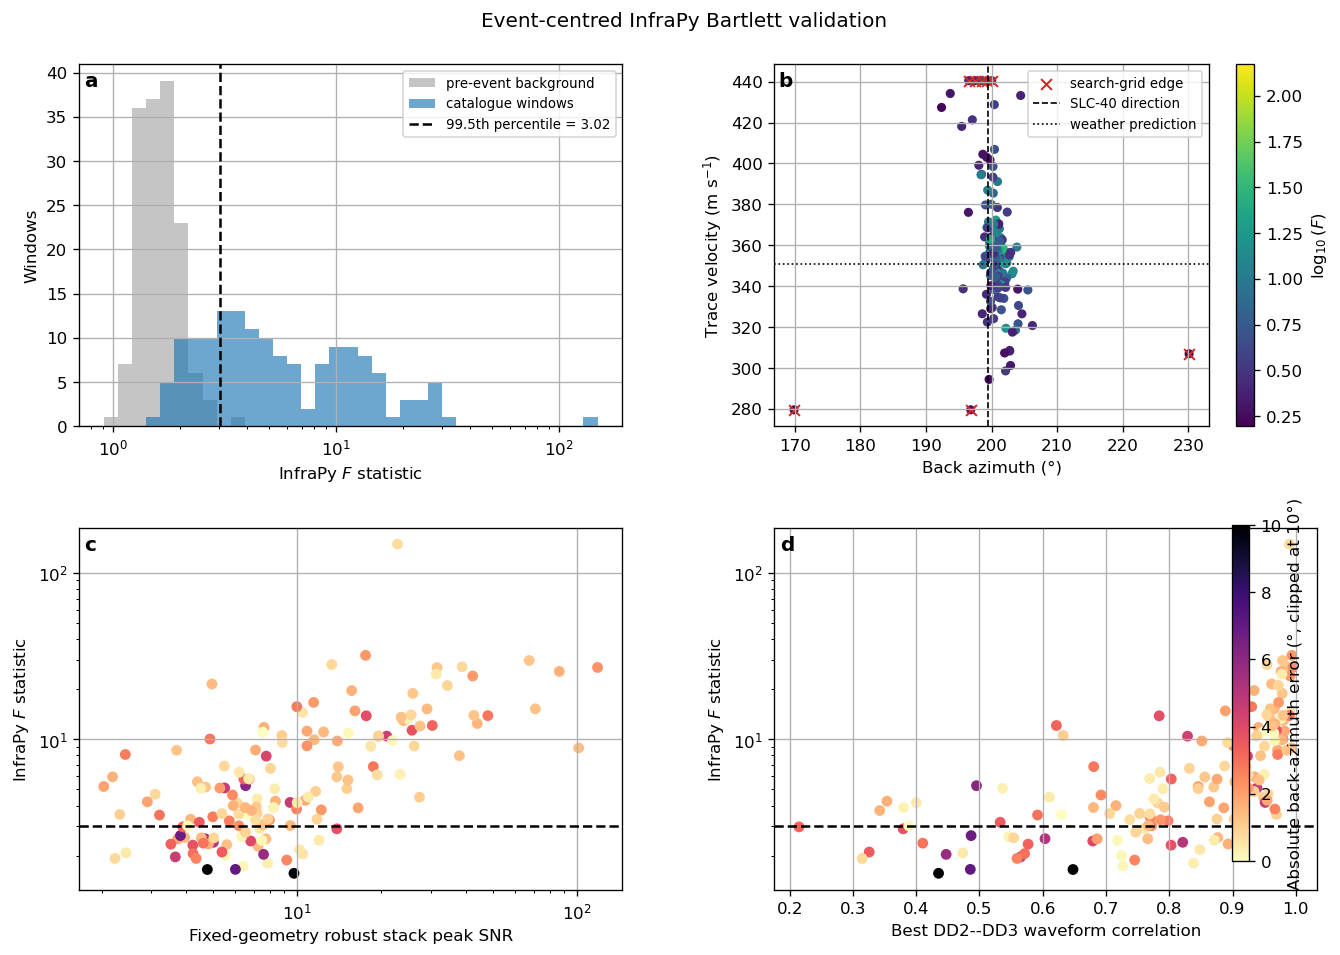

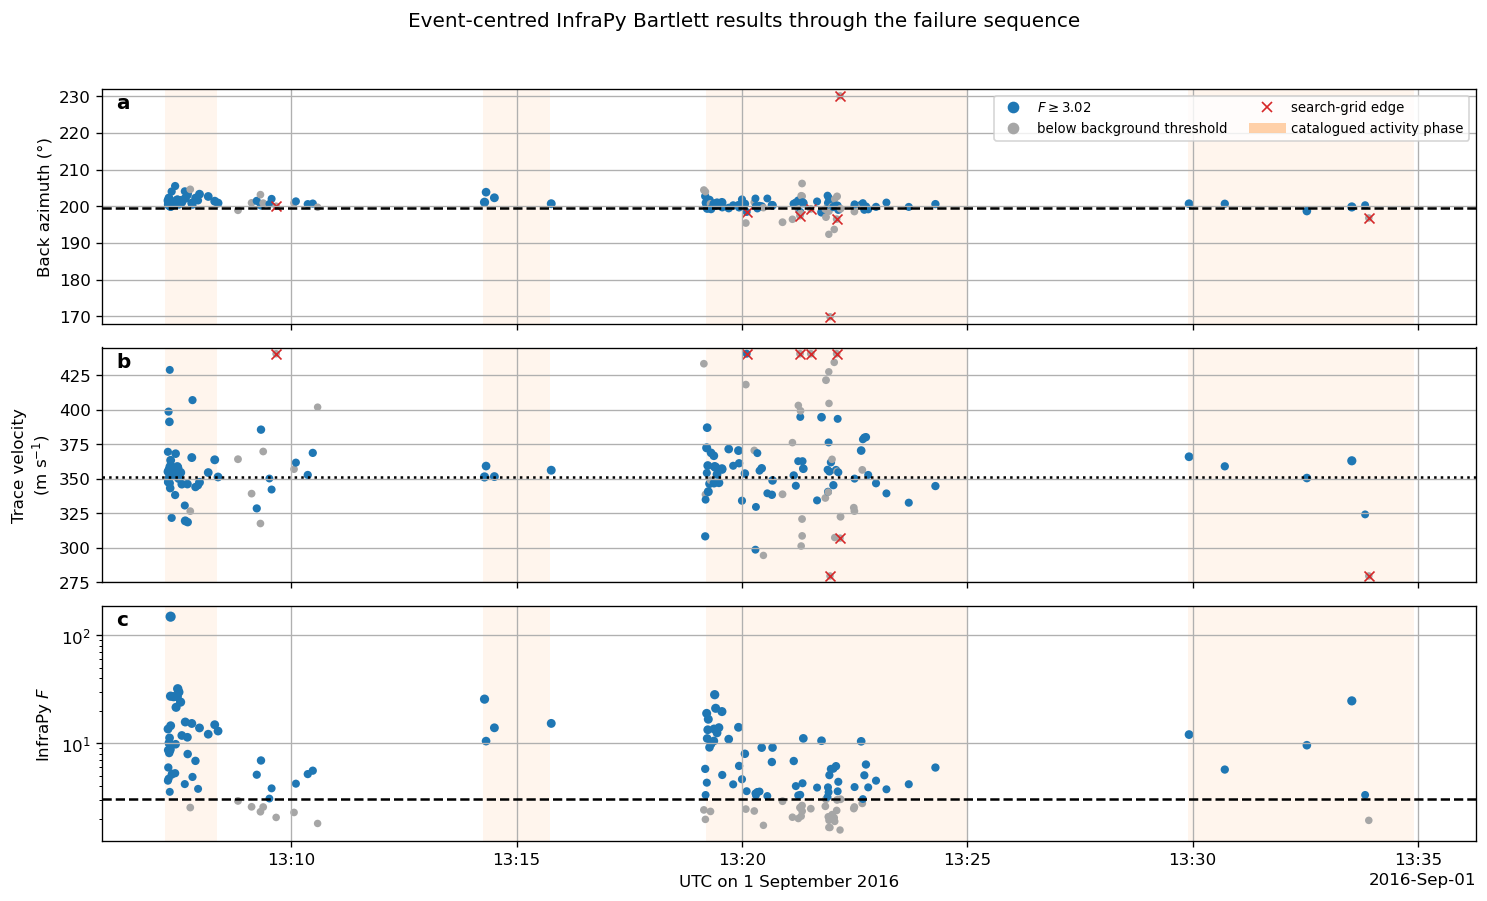

In [11]:
from matplotlib.dates import AutoDateLocator, ConciseDateFormatter
from matplotlib.lines import Line2D


def add_panel_labels(axes, labels=None):
    flat_axes = np.asarray(axes, dtype=object).ravel()
    labels = labels or [chr(ord("a") + index) for index in range(len(flat_axes))]
    for axis, label in zip(flat_axes, labels):
        axis.text(
            0.01, 0.98, label, transform=axis.transAxes,
            ha="left", va="top", fontweight="bold", fontsize=12,
        )


# Detailed supplementary validation figure.
event_validation_figure, axes = plt.subplots(2, 2, figsize=(12, 8))

positive_f = pd.concat(
    [background_beams["f_stat"], event_validation["f_stat"]],
    ignore_index=True,
).dropna()
positive_f = positive_f[positive_f > 0.0]
f_bins = np.geomspace(positive_f.min(), positive_f.max(), 36)
axes[0, 0].hist(
    background_beams["f_stat"], bins=f_bins, alpha=0.65,
    label="pre-event background", color="0.65",
)
axes[0, 0].hist(
    event_validation["f_stat"].dropna(), bins=f_bins, alpha=0.65,
    label="catalogue windows", color="tab:blue",
)
axes[0, 0].axvline(
    empirical_f_threshold, color="k", ls="--",
    label=f"99.5th percentile = {empirical_f_threshold:.2f}",
)
axes[0, 0].set_xscale("log")
axes[0, 0].set_xlabel("InfraPy $F$ statistic")
axes[0, 0].set_ylabel("Windows")
axes[0, 0].legend(fontsize=8)

scatter_f = axes[0, 1].scatter(
    event_validation["back_azimuth_deg"],
    event_validation["trace_velocity_mps"],
    c=np.log10(event_validation["f_stat"].clip(lower=1e-6)),
    s=30, cmap="viridis", edgecolors="none",
)
edge_mask = (
    event_validation["back_azimuth_grid_edge"]
    | event_validation["trace_velocity_grid_edge"]
)
axes[0, 1].scatter(
    event_validation.loc[edge_mask, "back_azimuth_deg"],
    event_validation.loc[edge_mask, "trace_velocity_mps"],
    marker="x", s=42, color="tab:red", linewidths=1.2,
    label="search-grid edge",
)
axes[0, 1].axvline(
    EXPECTED_BACK_AZIMUTH_DEG, color="k", ls="--", lw=1.0,
    label="SLC-40 direction",
)
axes[0, 1].axhline(
    METEOROLOGICAL_EFFECTIVE_SPEED_DISPLAY_MPS,
    color="k", ls=":", lw=1.0, label="weather prediction",
)
axes[0, 1].set_xlabel("Back azimuth (°)")
axes[0, 1].set_ylabel("Trace velocity (m s$^{-1}$)")
axes[0, 1].legend(fontsize=8, loc="best")
event_validation_figure.colorbar(
    scatter_f, ax=axes[0, 1], label="$\\log_{10}(F)$",
)

absolute_error = event_validation["back_azimuth_error_deg"].abs()
scatter_snr = axes[1, 0].scatter(
    event_validation["waveform_robust_stack_peak_snr"],
    event_validation["f_stat"], c=absolute_error,
    cmap="magma_r", s=30, vmin=0.0, vmax=10.0,
)
axes[1, 0].axhline(empirical_f_threshold, color="k", ls="--")
axes[1, 0].set_xscale("log")
axes[1, 0].set_yscale("log")
axes[1, 0].set_xlabel("Fixed-geometry robust stack peak SNR")
axes[1, 0].set_ylabel("InfraPy $F$ statistic")

scatter_correlation = axes[1, 1].scatter(
    event_validation["waveform_pair_best_correlation"],
    event_validation["f_stat"], c=absolute_error,
    cmap="magma_r", s=30, vmin=0.0, vmax=10.0,
)
axes[1, 1].axhline(empirical_f_threshold, color="k", ls="--")
axes[1, 1].set_yscale("log")
axes[1, 1].set_xlabel(
    f"Best {quality_pair[0]}--{quality_pair[1]} waveform correlation"
)
axes[1, 1].set_ylabel("InfraPy $F$ statistic")
event_validation_figure.colorbar(
    scatter_correlation, ax=axes[1, :].tolist(),
    label="Absolute back-azimuth error (°, clipped at 10°)",
    fraction=0.025, pad=0.03,
)
add_panel_labels(axes)
event_validation_figure.suptitle(
    "Event-centred InfraPy Bartlett validation", y=0.995
)
event_validation_figure.subplots_adjust(
    left=0.08, right=0.94, bottom=0.08, top=0.94,
    wspace=0.28, hspace=0.28,
)


# Compact main-paper figure: one point per catalogue entry through UTC.
catalogue_summary_figure, summary_axes = plt.subplots(
    3, 1, figsize=(12.5, 7.5), sharex=True,
)
event_times_utc = pd.to_datetime(
    event_validation["beam_centre_epoch_s"], unit="s", utc=True,
)
above_background = event_validation["above_empirical_background_threshold"]
point_colors = np.where(above_background, "tab:blue", "0.65")
point_sizes = 18.0 + 9.0 * np.log10(event_validation["f_stat"].clip(lower=1.0))

for axis in summary_axes:
    for phase_label, phase_start, phase_end in config.OVERVIEW_PHASE_INTERVALS:
        start = pd.to_datetime(float(phase_start.timestamp), unit="s", utc=True)
        end = pd.to_datetime(float(phase_end.timestamp), unit="s", utc=True)
        axis.axvspan(start, end, color="tab:orange", alpha=0.07, lw=0)

summary_axes[0].scatter(
    event_times_utc, event_validation["back_azimuth_deg"],
    c=point_colors, s=point_sizes, edgecolors="none",
)
summary_axes[0].scatter(
    event_times_utc[edge_mask],
    event_validation.loc[edge_mask, "back_azimuth_deg"],
    marker="x", s=36, color="tab:red", linewidths=1.0,
)
summary_axes[0].axhline(EXPECTED_BACK_AZIMUTH_DEG, color="k", ls="--")
summary_axes[0].set_ylabel("Back azimuth (°)")
summary_axes[0].set_ylim(168, 232)

summary_axes[1].scatter(
    event_times_utc, event_validation["trace_velocity_mps"],
    c=point_colors, s=point_sizes, edgecolors="none",
)
summary_axes[1].scatter(
    event_times_utc[edge_mask],
    event_validation.loc[edge_mask, "trace_velocity_mps"],
    marker="x", s=36, color="tab:red", linewidths=1.0,
)
summary_axes[1].axhline(
    METEOROLOGICAL_EFFECTIVE_SPEED_DISPLAY_MPS, color="k", ls=":"
)
summary_axes[1].set_ylabel("Trace velocity\n(m s$^{-1}$)")
summary_axes[1].set_ylim(275, 445)

summary_axes[2].scatter(
    event_times_utc, event_validation["f_stat"],
    c=point_colors, s=point_sizes, edgecolors="none",
)
summary_axes[2].axhline(empirical_f_threshold, color="k", ls="--")
summary_axes[2].set_yscale("log")
summary_axes[2].set_ylabel("InfraPy $F$")
summary_axes[2].set_xlabel("UTC on 1 September 2016")

locator = AutoDateLocator(minticks=5, maxticks=10)
summary_axes[2].xaxis.set_major_locator(locator)
summary_axes[2].xaxis.set_major_formatter(ConciseDateFormatter(locator))
legend_handles = [
    Line2D([], [], marker="o", linestyle="none", color="tab:blue",
           label=f"$F \\geq {empirical_f_threshold:.2f}$"),
    Line2D([], [], marker="o", linestyle="none", color="0.65",
           label="below background threshold"),
    Line2D([], [], marker="x", linestyle="none", color="tab:red",
           label="search-grid edge"),
    Line2D([], [], color="tab:orange", alpha=0.35, lw=6,
           label="catalogued activity phase"),
]
summary_axes[0].legend(
    handles=legend_handles, ncol=2, fontsize=8, loc="upper right",
)
add_panel_labels(summary_axes)
catalogue_summary_figure.suptitle(
    "Event-centred InfraPy Bartlett results through the failure sequence",
    y=0.995,
)
catalogue_summary_figure.tight_layout(rect=(0, 0, 1, 0.97))

## 7. Optional blind continuous scan and InfraPy detection grouping

This section runs only for a continuous mode. It does not use manual event times
to place its analysis windows or set its threshold. The fixed F threshold is
estimated from the independent pre-event background.

Two deliberately different products are retained:

1. InfraPy `run_fd` groups sequential above-threshold windows with consistent
   back azimuth into **activity episodes**. In the dense opening sequence it may
   merge many explosions into one episode and must not be used as the event
   count.
2. Local maxima of the continuous F-statistic series provide **blind peak
   candidates**. These can be matched one-to-one to the manual catalogue, but
   their resolution is limited by the 0.5-s beam window and 0.1-s step.

Because the 0.5-s windows overlap, adjacent detections are not independent. The
minimum sequence, window length, step, frequency band, and threshold quantile
must therefore be reported together and tested for sensitivity.

continuous_full: 1/17,839 windows; 0.0 s
continuous_full: 100/17,839 windows; 1.5 s
continuous_full: 200/17,839 windows; 3.0 s
continuous_full: 300/17,839 windows; 4.5 s
continuous_full: 400/17,839 windows; 5.9 s
continuous_full: 500/17,839 windows; 7.4 s
continuous_full: 600/17,839 windows; 8.9 s
continuous_full: 700/17,839 windows; 10.4 s
continuous_full: 800/17,839 windows; 11.9 s
continuous_full: 900/17,839 windows; 13.4 s
continuous_full: 1,000/17,839 windows; 14.8 s
continuous_full: 1,100/17,839 windows; 16.3 s
continuous_full: 1,200/17,839 windows; 17.7 s
continuous_full: 1,300/17,839 windows; 19.2 s
continuous_full: 1,400/17,839 windows; 20.6 s
continuous_full: 1,500/17,839 windows; 22.1 s
continuous_full: 1,600/17,839 windows; 23.5 s
continuous_full: 1,700/17,839 windows; 24.9 s
continuous_full: 1,800/17,839 windows; 26.4 s
continuous_full: 1,900/17,839 windows; 27.8 s
continuous_full: 2,000/17,839 windows; 29.2 s
continuous_full: 2,100/17,839 windows; 30.7 s
continuous_full: 

,quality_tier,catalogue_count,matched_count,recovery_percent
0,Full catalogue,153,129,84.313725
1,Usable waveform,132,119,90.151515
2,Core waveform,100,90,90.000000
3,Event-centred $F \geq 5$,77,75,97.402597
4,Event-centred $F \geq 10$,42,41,97.619048


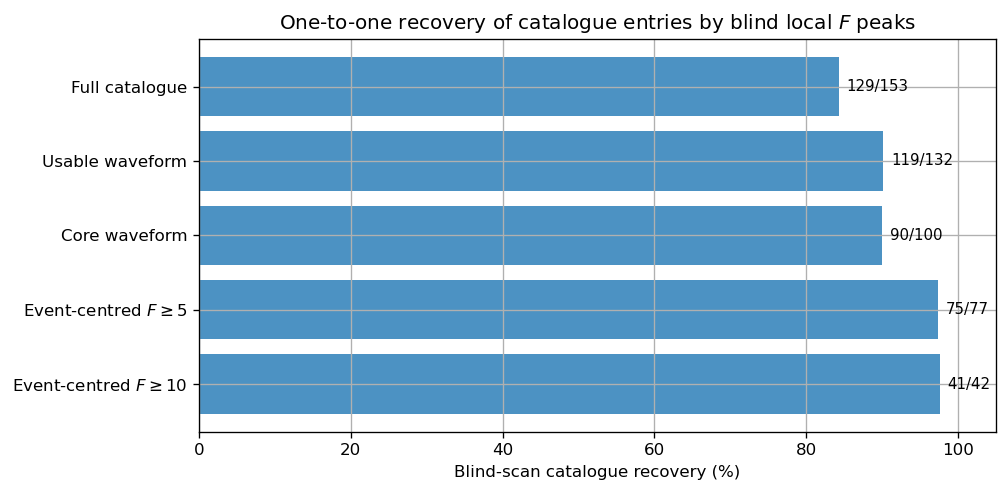

In [12]:
continuous_beams = pd.DataFrame()
continuous_activity_episodes = pd.DataFrame()
blind_peak_candidates = pd.DataFrame()
manual_recovery = pd.DataFrame()
recovery_by_quality = pd.DataFrame()
priority_unmatched_peaks = pd.DataFrame()
continuous_figure = None
recovery_figure = None

if len(selected_continuous_centres):
    continuous_beams = beamform_windows(
        pressure_stream,
        latlon,
        selected_continuous_centres,
        window_length_s=WINDOW_LENGTH_S,
        freq_band_hz=(FREQ_MIN_HZ, FREQ_MAX_HZ),
        back_azimuth_values_deg=CONTINUOUS_BACK_AZIMUTH_VALUES_DEG,
        trace_velocity_values_mps=CONTINUOUS_TRACE_VELOCITY_VALUES_MPS,
        label=RUN_MODE,
    )

    times_np = pd.to_datetime(
        continuous_beams["beam_centre_epoch_s"], unit="s", utc=True
    ).to_numpy(dtype="datetime64[ms]")
    peak_matrix = continuous_beams[
        ["back_azimuth_deg", "trace_velocity_mps", "f_stat"]
    ].to_numpy(float)

    time_bandwidth_product = max(
        1, int(round(WINDOW_LENGTH_S * (FREQ_MAX_HZ - FREQ_MIN_HZ)))
    )
    detections = infrapy_bf.run_fd(
        times_np,
        peak_matrix,
        win_len=max(30.0, 20.0 * WINDOW_LENGTH_S),
        TB_prod=time_bandwidth_product,
        channel_cnt=len(pressure_channels),
        det_p_val=0.99,
        min_seq=MIN_DETECTION_WINDOWS,
        back_az_lim=MAX_BACK_AZIMUTH_STD_95_DEG,
        fixed_thresh=empirical_f_threshold,
        merge_dets=True,
    )

    continuous_activity_episodes = pd.DataFrame(
        detections,
        columns=[
            "detection_time", "relative_start_s", "relative_end_s",
            "back_azimuth_deg", "trace_velocity_mps", "f_stat",
        ],
    )
    if not continuous_activity_episodes.empty:
        continuous_activity_episodes["detection_time"] = pd.to_datetime(
            continuous_activity_episodes["detection_time"], utc=True
        )
        continuous_activity_episodes["detection_epoch_s"] = (
            continuous_activity_episodes["detection_time"].astype("int64") / 1e9
        )
        continuous_activity_episodes["episode_start_time"] = (
            continuous_activity_episodes["detection_time"]
            + pd.to_timedelta(
                continuous_activity_episodes["relative_start_s"], unit="s"
            )
        )
        continuous_activity_episodes["episode_end_time"] = (
            continuous_activity_episodes["detection_time"]
            + pd.to_timedelta(
                continuous_activity_episodes["relative_end_s"], unit="s"
            )
        )
        continuous_activity_episodes["back_azimuth_error_deg"] = (
            circular_difference_deg(
                continuous_activity_episodes["back_azimuth_deg"],
                EXPECTED_BACK_AZIMUTH_DEG,
            )
        )

    # Local maxima are candidates from overlapping windows, not event counts.
    background_f_scale = robust_scale(background_beams["f_stat"])
    minimum_prominence = BLIND_PEAK_MINIMUM_PROMINENCE_MAD * background_f_scale
    minimum_peak_distance_samples = max(
        1, int(np.ceil(BLIND_PEAK_MINIMUM_SEPARATION_S / WINDOW_STEP_S))
    )
    peak_indices, peak_properties = find_peaks(
        continuous_beams["f_stat"].to_numpy(float),
        height=empirical_f_threshold,
        prominence=minimum_prominence,
        distance=minimum_peak_distance_samples,
    )
    blind_peak_candidates = (
        continuous_beams.iloc[peak_indices].copy().reset_index(drop=True)
    )
    blind_peak_candidates.insert(
        0, "blind_peak_number", np.arange(1, len(blind_peak_candidates) + 1)
    )
    if len(blind_peak_candidates):
        blind_peak_candidates["f_prominence"] = peak_properties["prominences"]
        blind_peak_candidates["matched_catalogue_event_number"] = pd.NA

    manual_recovery = event_validation[
        [
            "final_event_number", "reduced_event_epoch_s", "reduced_event_time",
            "waveform_robust_stack_peak_snr", "waveform_pair_best_correlation",
            "f_stat", "above_empirical_background_threshold",
        ]
    ].copy()
    manual_recovery["blind_peak_number"] = pd.NA
    manual_recovery["peak_minus_event_s"] = np.nan
    manual_recovery["matched"] = False

    candidate_pairs = []
    for event_index, event in manual_recovery.iterrows():
        for peak_index, peak in blind_peak_candidates.iterrows():
            difference_s = float(
                peak["beam_centre_epoch_s"] - event["reduced_event_epoch_s"]
            )
            if abs(difference_s) <= MATCH_TOLERANCE_S:
                candidate_pairs.append(
                    (abs(difference_s), event_index, peak_index, difference_s)
                )
    used_events, used_peaks = set(), set()
    for _, event_index, peak_index, difference_s in sorted(candidate_pairs):
        if event_index in used_events or peak_index in used_peaks:
            continue
        used_events.add(event_index)
        used_peaks.add(peak_index)
        event_number = int(manual_recovery.loc[event_index, "final_event_number"])
        peak_number = int(blind_peak_candidates.loc[peak_index, "blind_peak_number"])
        manual_recovery.loc[event_index, "blind_peak_number"] = peak_number
        manual_recovery.loc[event_index, "peak_minus_event_s"] = difference_s
        manual_recovery.loc[event_index, "matched"] = True
        blind_peak_candidates.loc[
            peak_index, "matched_catalogue_event_number"
        ] = event_number

    if not blind_peak_candidates.empty:
        blind_peak_candidates["matched_to_catalogue"] = (
            blind_peak_candidates["matched_catalogue_event_number"].notna()
        )
        blind_peak_candidates["physically_consistent_direction"] = (
            blind_peak_candidates["back_azimuth_error_deg"].abs()
            <= PRIORITY_BACK_AZIMUTH_TOLERANCE_DEG
        )
        blind_peak_candidates["physically_consistent_velocity"] = (
            blind_peak_candidates["trace_velocity_mps"].between(
                *PRIORITY_TRACE_VELOCITY_RANGE_MPS
            )
        )
        blind_peak_candidates["priority_unmatched_peak"] = (
            ~blind_peak_candidates["matched_to_catalogue"]
            & blind_peak_candidates["physically_consistent_direction"]
            & blind_peak_candidates["physically_consistent_velocity"]
            & ~blind_peak_candidates["back_azimuth_grid_edge"]
            & ~blind_peak_candidates["trace_velocity_grid_edge"]
        )
        priority_unmatched_peaks = blind_peak_candidates.loc[
            blind_peak_candidates["priority_unmatched_peak"]
        ].copy()

    quality_masks = {
        "Full catalogue": np.ones(len(manual_recovery), dtype=bool),
        "Usable waveform": (
            (manual_recovery["waveform_robust_stack_peak_snr"] >= 3.0)
            & (manual_recovery["waveform_pair_best_correlation"] >= 0.5)
        ),
        "Core waveform": (
            (manual_recovery["waveform_robust_stack_peak_snr"] >= 5.0)
            & (manual_recovery["waveform_pair_best_correlation"] >= 0.7)
        ),
        "Event-centred $F \\geq 5$": manual_recovery["f_stat"] >= 5.0,
        "Event-centred $F \\geq 10$": manual_recovery["f_stat"] >= 10.0,
    }
    recovery_rows = []
    for label, mask in quality_masks.items():
        selected = manual_recovery.loc[np.asarray(mask, dtype=bool)]
        matched_count = int(selected["matched"].sum())
        recovery_rows.append(
            {
                "quality_tier": label,
                "catalogue_count": len(selected),
                "matched_count": matched_count,
                "recovery_percent": 100.0 * matched_count / len(selected),
            }
        )
    recovery_by_quality = pd.DataFrame(recovery_rows)

    recovery_figure, recovery_axis = plt.subplots(figsize=(8.5, 4.2))
    bars = recovery_axis.barh(
        recovery_by_quality["quality_tier"],
        recovery_by_quality["recovery_percent"],
        color="tab:blue", alpha=0.8,
    )
    recovery_axis.set_xlim(0, 105)
    recovery_axis.set_xlabel("Blind-scan catalogue recovery (%)")
    recovery_axis.set_ylabel("")
    recovery_axis.invert_yaxis()
    for bar, row in zip(bars, recovery_by_quality.itertuples()):
        recovery_axis.text(
            min(row.recovery_percent + 1.0, 101.0),
            bar.get_y() + bar.get_height() / 2.0,
            f"{row.matched_count}/{row.catalogue_count}",
            va="center", fontsize=9,
        )
    recovery_axis.set_title(
        "One-to-one recovery of catalogue entries by blind local $F$ peaks"
    )
    recovery_figure.tight_layout()

    print("InfraPy activity episodes:", len(continuous_activity_episodes))
    print("Blind local F peaks:", len(blind_peak_candidates))
    print("Catalogue entries matched one-to-one:", int(manual_recovery["matched"].sum()))
    print("Unmatched blind peaks:", len(blind_peak_candidates) - len(used_peaks))
    print("Priority unmatched peaks for review:", len(priority_unmatched_peaks))
    display(recovery_by_quality)
else:
    print("Continuous scan skipped in event_validation mode.")

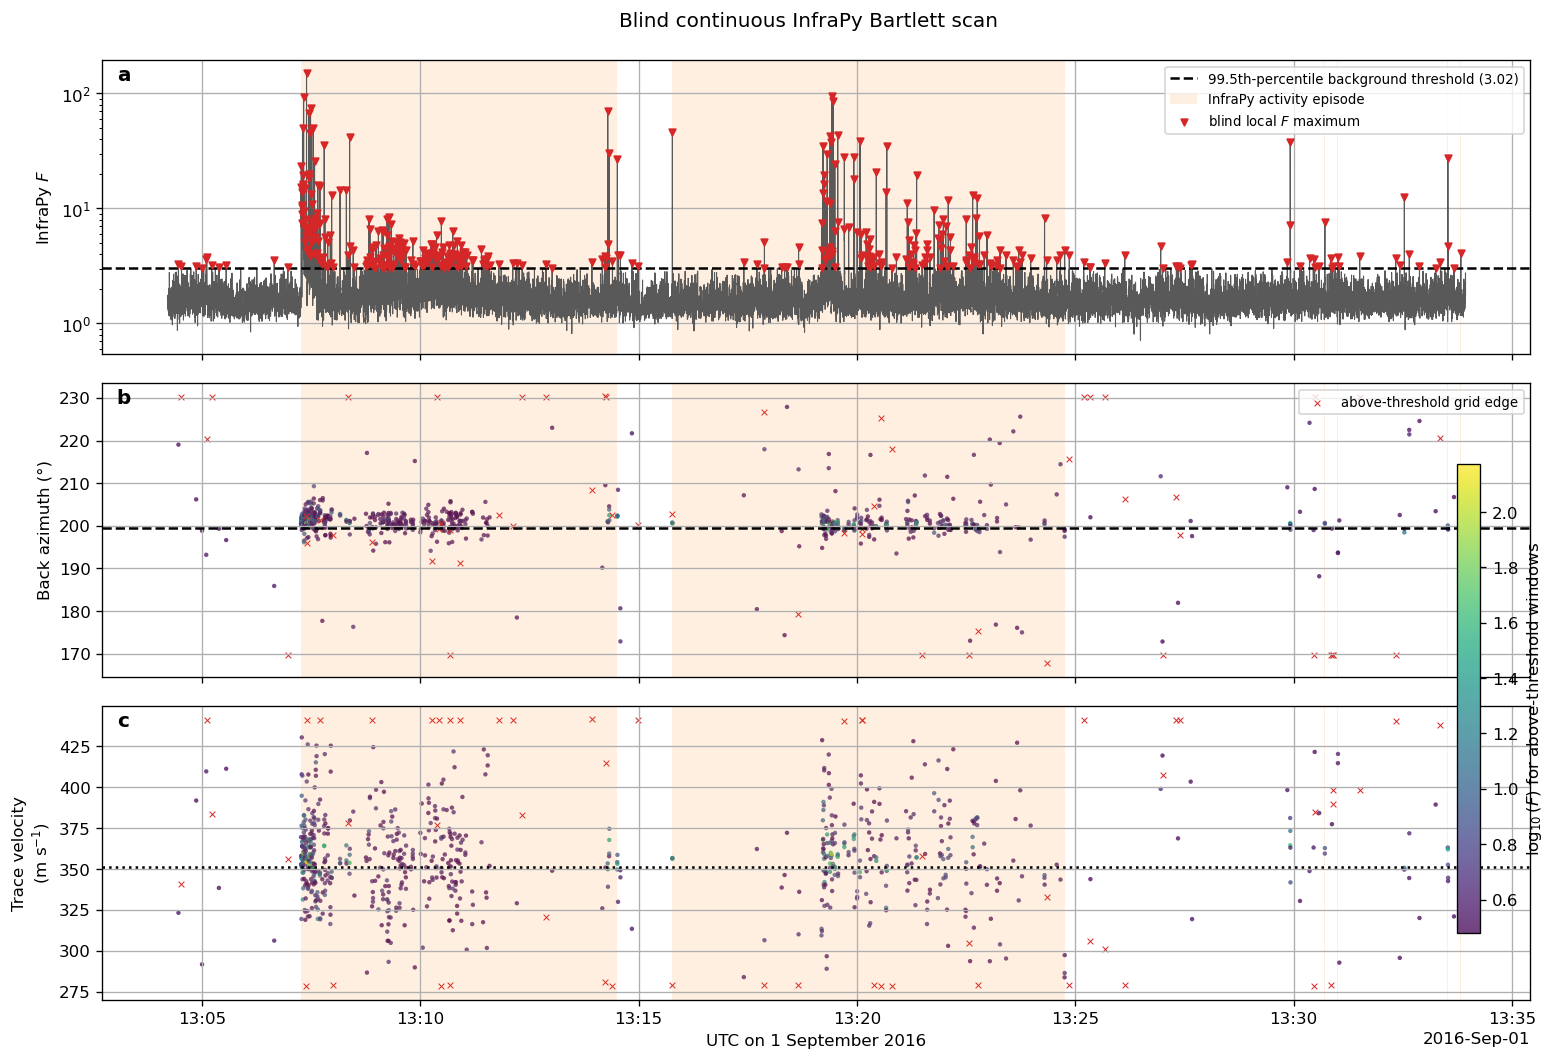

In [13]:
if not continuous_beams.empty:
    continuous_figure, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
    times = pd.to_datetime(
        continuous_beams["beam_centre_epoch_s"], unit="s", utc=True
    )
    above_threshold = continuous_beams["f_stat"] >= empirical_f_threshold
    non_edge = ~(
        continuous_beams["back_azimuth_grid_edge"]
        | continuous_beams["trace_velocity_grid_edge"]
    )
    display_mask = above_threshold & non_edge
    edge_display_mask = above_threshold & ~non_edge

    axes[0].plot(times, continuous_beams["f_stat"], lw=0.65, color="0.35")
    axes[0].axhline(
        empirical_f_threshold, color="k", ls="--",
        label=f"99.5th-percentile background threshold ({empirical_f_threshold:.2f})",
    )
    axes[0].set_yscale("log")
    axes[0].set_ylabel("InfraPy $F$")

    # Direction and speed are shown only for coherent above-threshold windows;
    # low-F search-grid maxima otherwise obscure the event sequence.
    color_values = np.log10(
        continuous_beams.loc[display_mask, "f_stat"].clip(lower=1e-6)
    )
    direction_scatter = axes[1].scatter(
        times[display_mask],
        continuous_beams.loc[display_mask, "back_azimuth_deg"],
        c=color_values, s=7, cmap="viridis", alpha=0.75, edgecolors="none",
    )
    axes[1].scatter(
        times[edge_display_mask],
        continuous_beams.loc[edge_display_mask, "back_azimuth_deg"],
        marker="x", s=12, color="tab:red", linewidths=0.6,
        label="above-threshold grid edge",
    )
    axes[1].axhline(EXPECTED_BACK_AZIMUTH_DEG, color="k", ls="--")
    axes[1].set_ylabel("Back azimuth (°)")
    axes[1].legend(fontsize=8, loc="upper right")

    axes[2].scatter(
        times[display_mask],
        continuous_beams.loc[display_mask, "trace_velocity_mps"],
        c=color_values, s=7, cmap="viridis", alpha=0.75, edgecolors="none",
    )
    axes[2].scatter(
        times[edge_display_mask],
        continuous_beams.loc[edge_display_mask, "trace_velocity_mps"],
        marker="x", s=12, color="tab:red", linewidths=0.6,
    )
    axes[2].axhline(
        METEOROLOGICAL_EFFECTIVE_SPEED_DISPLAY_MPS, color="k", ls=":"
    )
    axes[2].set_ylabel("Trace velocity\n(m s$^{-1}$)")
    axes[2].set_xlabel("UTC on 1 September 2016")

    if not continuous_activity_episodes.empty:
        first_span = True
        for episode in continuous_activity_episodes.itertuples():
            for axis in axes:
                axis.axvspan(
                    episode.episode_start_time,
                    episode.episode_end_time,
                    color="tab:orange", alpha=0.12, lw=0,
                    label="InfraPy activity episode" if first_span and axis is axes[0] else None,
                )
            first_span = False
    if not blind_peak_candidates.empty:
        peak_times = pd.to_datetime(
            blind_peak_candidates["beam_centre_epoch_s"], unit="s", utc=True
        )
        axes[0].scatter(
            peak_times, blind_peak_candidates["f_stat"],
            marker="v", s=16, color="tab:red",
            label="blind local $F$ maximum", zorder=4,
        )

    axes[0].legend(loc="upper right", fontsize=8)
    continuous_figure.colorbar(
        direction_scatter, ax=axes[1:],
        label="$\\log_{10}(F)$ for above-threshold windows",
        fraction=0.018, pad=0.02,
    )
    locator = AutoDateLocator(minticks=5, maxticks=10)
    axes[2].xaxis.set_major_locator(locator)
    axes[2].xaxis.set_major_formatter(ConciseDateFormatter(locator))
    add_panel_labels(axes)
    continuous_figure.suptitle(
        "Blind continuous InfraPy Bartlett scan", y=0.995
    )
    continuous_figure.subplots_adjust(
        left=0.08, right=0.93, bottom=0.08, top=0.95, hspace=0.10
    )

## 8. Parameter sensitivity

The event-centred analysis is repeated for adjacent window and passband
choices. Absolute $F$ values are not compared across configurations without
their corresponding background distributions because window length and
frequency band change the statistic's distribution. The primary configuration
is evaluated by directional error, trace-velocity stability, and grid-edge
behaviour rather than selected solely for catalogue recovery.

short_high: 1/153 windows; 0.0 s
short_high: 100/153 windows; 1.6 s
short_high: 153/153 windows; 2.5 s
primary: 1/153 windows; 0.0 s
primary: 100/153 windows; 1.8 s
primary: 153/153 windows; 2.7 s
broad_low: 1/153 windows; 0.0 s
broad_low: 100/153 windows; 1.8 s
broad_low: 153/153 windows; 2.7 s


,name,window_length_s,freq_band_hz,events_analyzed,median_back_azimuth_deg,median_abs_back_azimuth_error_deg,median_trace_velocity_mps,median_f_stat,back_azimuth_edge_hits,trace_velocity_edge_hits
0,short_high,0.25,"(4.0, 30.0)",153,200.835612,1.525018,369.862964,3.566527,0,33
1,primary,0.50,"(2.0, 20.0)",153,200.674635,1.432204,354.604130,5.035837,2,7
2,broad_low,1.00,"(1.0, 10.0)",153,201.421662,2.823902,354.697558,2.902693,7,49


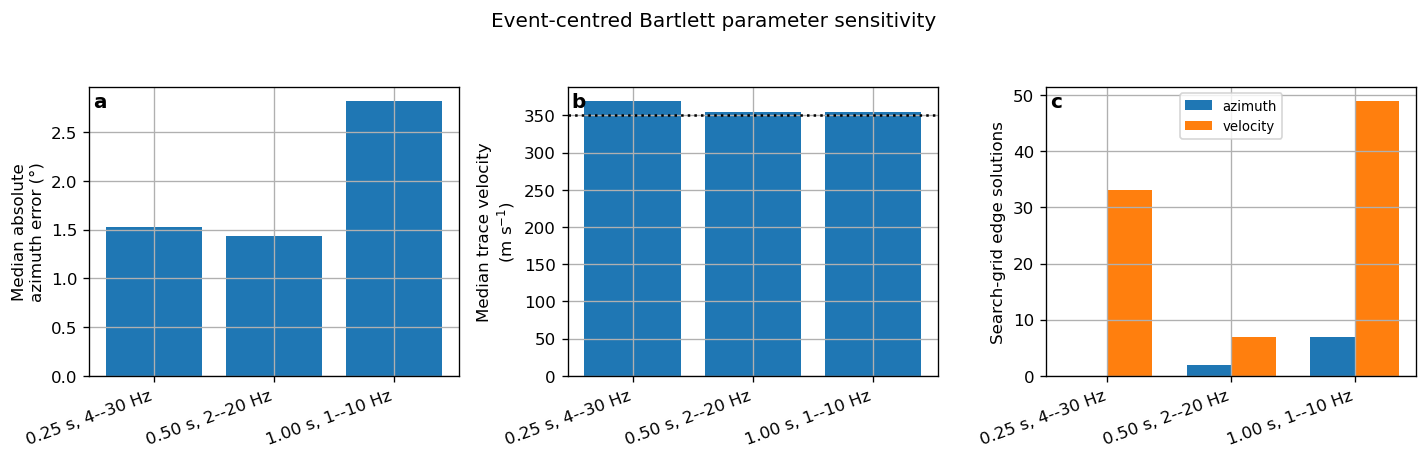

In [14]:
RUN_PARAMETER_SENSITIVITY = True
PARAMETER_SETS = [
    {"name": "short_high", "window_length_s": 0.25, "freq_band_hz": (4.0, 30.0)},
    {"name": "primary", "window_length_s": 0.50, "freq_band_hz": (2.0, 20.0)},
    {"name": "broad_low", "window_length_s": 1.00, "freq_band_hz": (1.0, 10.0)},
]

sensitivity_rows = []
if RUN_PARAMETER_SENSITIVITY:
    for parameter_set in PARAMETER_SETS:
        values = beamform_windows(
            pressure_stream,
            latlon,
            event_centres_epoch_s,
            window_length_s=parameter_set["window_length_s"],
            freq_band_hz=parameter_set["freq_band_hz"],
            back_azimuth_values_deg=BACK_AZIMUTH_VALUES_DEG,
            trace_velocity_values_mps=TRACE_VELOCITY_VALUES_MPS,
            label=parameter_set["name"],
        )
        sensitivity_rows.append(
            {
                **parameter_set,
                "events_analyzed": len(values),
                "median_back_azimuth_deg": values["back_azimuth_deg"].median(),
                "median_abs_back_azimuth_error_deg": values[
                    "back_azimuth_error_deg"
                ].abs().median(),
                "median_trace_velocity_mps": values["trace_velocity_mps"].median(),
                "median_f_stat": values["f_stat"].median(),
                "back_azimuth_edge_hits": int(values["back_azimuth_grid_edge"].sum()),
                "trace_velocity_edge_hits": int(values["trace_velocity_grid_edge"].sum()),
            }
        )

sensitivity_summary = pd.DataFrame(sensitivity_rows)
if not sensitivity_summary.empty:
    display(sensitivity_summary)

sensitivity_figure = None
if not sensitivity_summary.empty:
    display_labels = {
        "short_high": "0.25 s, 4--30 Hz",
        "primary": "0.50 s, 2--20 Hz",
        "broad_low": "1.00 s, 1--10 Hz",
    }
    sensitivity_plot = sensitivity_summary.copy()
    sensitivity_plot["display_label"] = sensitivity_plot["name"].map(display_labels)
    x = np.arange(len(sensitivity_plot))
    sensitivity_figure, sensitivity_axes = plt.subplots(1, 3, figsize=(12, 3.8))

    sensitivity_axes[0].bar(
        x, sensitivity_plot["median_abs_back_azimuth_error_deg"], color="tab:blue"
    )
    sensitivity_axes[0].set_ylabel("Median absolute\nazimuth error (°)")

    sensitivity_axes[1].bar(
        x, sensitivity_plot["median_trace_velocity_mps"], color="tab:blue"
    )
    sensitivity_axes[1].axhline(
        METEOROLOGICAL_EFFECTIVE_SPEED_DISPLAY_MPS, color="k", ls=":"
    )
    sensitivity_axes[1].set_ylabel("Median trace velocity\n(m s$^{-1}$)")

    width = 0.36
    sensitivity_axes[2].bar(
        x - width / 2, sensitivity_plot["back_azimuth_edge_hits"],
        width=width, label="azimuth", color="tab:blue",
    )
    sensitivity_axes[2].bar(
        x + width / 2, sensitivity_plot["trace_velocity_edge_hits"],
        width=width, label="velocity", color="tab:orange",
    )
    sensitivity_axes[2].set_ylabel("Search-grid edge solutions")
    sensitivity_axes[2].legend(fontsize=8)

    for axis in sensitivity_axes:
        axis.set_xticks(x)
        axis.set_xticklabels(sensitivity_plot["display_label"], rotation=20, ha="right")
    add_panel_labels(sensitivity_axes)
    sensitivity_figure.suptitle("Event-centred Bartlett parameter sensitivity", y=0.995)
    sensitivity_figure.tight_layout(rect=(0, 0, 1, 0.95))

## 9. Save auditable products and publication figures

In [15]:
OUTPUT_DIRECTORY.mkdir(parents=True, exist_ok=True)
FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)

event_validation_file = OUTPUT_DIRECTORY / "event_centred_bartlett_validation.csv"
background_file = OUTPUT_DIRECTORY / "pre_event_background_bartlett.csv"
metadata_file = OUTPUT_DIRECTORY / "infrapy_validation_metadata.json"
mode_metadata_file = OUTPUT_DIRECTORY / f"{RUN_MODE}_validation_metadata.json"

event_validation.to_csv(event_validation_file, index=False)
background_beams.to_csv(background_file, index=False)
waveform_quality.to_csv(OUTPUT_DIRECTORY / "event_waveform_quality.csv", index=False)
speed_quality_summary.to_csv(
    OUTPUT_DIRECTORY / "speed_quality_tier_summary.csv", index=False
)

event_validation_figure.savefig(
    FIGURE_DIRECTORY / "event_centred_bartlett_validation.pdf",
    bbox_inches="tight",
)
catalogue_summary_figure.savefig(
    FIGURE_DIRECTORY / "catalogue_bartlett_summary_utc_phase.pdf",
    bbox_inches="tight",
)

if not continuous_beams.empty:
    continuous_beams.to_csv(
        OUTPUT_DIRECTORY / f"{RUN_MODE}_beam_windows.csv", index=False
    )
if continuous_figure is not None:
    continuous_figure.savefig(
        FIGURE_DIRECTORY / f"{RUN_MODE}_beam_results.pdf",
        bbox_inches="tight",
    )
if not continuous_activity_episodes.empty:
    continuous_activity_episodes.to_csv(
        OUTPUT_DIRECTORY / f"{RUN_MODE}_activity_episodes.csv", index=False
    )
if not blind_peak_candidates.empty:
    blind_peak_candidates.to_csv(
        OUTPUT_DIRECTORY / f"{RUN_MODE}_blind_peak_candidates.csv", index=False
    )
if not priority_unmatched_peaks.empty:
    priority_unmatched_peaks.to_csv(
        OUTPUT_DIRECTORY / f"{RUN_MODE}_priority_unmatched_peaks.csv", index=False
    )
if not manual_recovery.empty:
    manual_recovery.to_csv(
        OUTPUT_DIRECTORY / f"{RUN_MODE}_catalogue_recovery.csv", index=False
    )
if not recovery_by_quality.empty:
    recovery_by_quality.to_csv(
        OUTPUT_DIRECTORY / f"{RUN_MODE}_recovery_by_quality_tier.csv", index=False
    )
if recovery_figure is not None:
    recovery_figure.savefig(
        FIGURE_DIRECTORY / f"{RUN_MODE}_recovery_by_quality_tier.pdf",
        bbox_inches="tight",
    )
if not sensitivity_summary.empty:
    sensitivity_summary.to_csv(
        OUTPUT_DIRECTORY / "parameter_sensitivity_summary.csv", index=False
    )
if sensitivity_figure is not None:
    sensitivity_figure.savefig(
        FIGURE_DIRECTORY / "parameter_sensitivity_summary.pdf",
        bbox_inches="tight",
    )

provenance = {
    "schema_version": 2,
    "notebook": "040_validate_event_catalogue_with_array_processing.ipynb",
    "run_mode": RUN_MODE,
    "infrapy_version": INFRAPY_VERSION,
    "infrapy_module_file": str(INFRAPY_MODULE_FILE),
    "python_version": platform.python_version(),
    "input_files": {
        "analysis_configuration": str(ANALYSIS_CONFIG_FILE),
        "baseline_corrected_stream": str(BASELINE_STREAM_FILE),
        "geometry": str(geometry_file),
        "catalogue": str(FINAL_CATALOGUE_FILE),
        "weather_acoustic_summary": str(WEATHER_ACOUSTIC_SUMMARY_FILE),
    },
    "pressure_channels": pressure_channels,
    "sampling_rate_hz": sampling_rate_hz,
    "method": METHOD,
    "frequency_band_hz": [FREQ_MIN_HZ, FREQ_MAX_HZ],
    "window_length_s": WINDOW_LENGTH_S,
    "window_step_s": WINDOW_STEP_S,
    "back_azimuth_grid_deg": [
        float(BACK_AZIMUTH_VALUES_DEG[0]),
        float(BACK_AZIMUTH_VALUES_DEG[-1]),
        float(np.diff(BACK_AZIMUTH_VALUES_DEG).min()),
    ],
    "trace_velocity_grid_mps": [
        float(TRACE_VELOCITY_VALUES_MPS[0]),
        float(TRACE_VELOCITY_VALUES_MPS[-1]),
        float(np.diff(TRACE_VELOCITY_VALUES_MPS).min()),
    ],
    "continuous_back_azimuth_grid_deg": [
        float(CONTINUOUS_BACK_AZIMUTH_VALUES_DEG[0]),
        float(CONTINUOUS_BACK_AZIMUTH_VALUES_DEG[-1]),
        float(np.diff(CONTINUOUS_BACK_AZIMUTH_VALUES_DEG).min()),
    ],
    "continuous_trace_velocity_grid_mps": [
        float(CONTINUOUS_TRACE_VELOCITY_VALUES_MPS[0]),
        float(CONTINUOUS_TRACE_VELOCITY_VALUES_MPS[-1]),
        float(np.diff(CONTINUOUS_TRACE_VELOCITY_VALUES_MPS).min()),
    ],
    "expected_back_azimuth_deg": EXPECTED_BACK_AZIMUTH_DEG,
    "meteorological_effective_speed_mps": METEOROLOGICAL_EFFECTIVE_SPEED_MPS,
    "meteorological_effective_speed_display_mps": (
        METEOROLOGICAL_EFFECTIVE_SPEED_DISPLAY_MPS
    ),
    "background_f_quantile": BACKGROUND_F_QUANTILE,
    "empirical_f_threshold": empirical_f_threshold,
    "minimum_detection_windows": MIN_DETECTION_WINDOWS,
    "catalogue_match_tolerance_s": MATCH_TOLERANCE_S,
    "blind_peak_minimum_separation_s": BLIND_PEAK_MINIMUM_SEPARATION_S,
    "blind_peak_minimum_prominence_mad": BLIND_PEAK_MINIMUM_PROMINENCE_MAD,
    "priority_back_azimuth_tolerance_deg": PRIORITY_BACK_AZIMUTH_TOLERANCE_DEG,
    "priority_trace_velocity_range_mps": list(PRIORITY_TRACE_VELOCITY_RANGE_MPS),
}
metadata_file.write_text(json.dumps(provenance, indent=2) + "\n", encoding="utf-8")
mode_metadata_file.write_text(
    json.dumps(provenance, indent=2) + "\n", encoding="utf-8"
)

print("Wrote", event_validation_file)
print("Wrote", background_file)
print("Wrote", metadata_file)
print("Wrote", mode_metadata_file)

Wrote /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/040_validate_event_catalogue_with_array_processing/event_centred_bartlett_validation.csv
Wrote /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/040_validate_event_catalogue_with_array_processing/pre_event_background_bartlett.csv
Wrote /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/040_validate_event_catalogue_with_array_processing/infrapy_validation_metadata.json
Wrote /Users/thompsong/Developer/KSCRocketSeismology/08_fireball_paper/falcon9-seismoacoustic-workflow-1.0.0/data/outputs/040_validate_event_catalogue_with_array_processing/continuous_full_validation_metadata.json


## Interpretation and reporting checklist

1. Event-centred Bartlett results validate source direction, apparent trace
   velocity, and array coherence for catalogue-selected windows. They do not
   independently establish the number of physical explosions.
2. The blind continuous scan is a separate completeness diagnostic. Its local
   maxima and broader activity episodes are not event counts because 0.5-s
   windows overlap at 0.1-s steps and oscillatory signals can produce several
   maxima.
3. Direction and velocity from low-$F$ windows are intentionally suppressed in
   the continuous figure because their grid-maximizing values are not stable
   physical measurements.
4. Search-grid-edge solutions are flagged explicitly rather than silently
   rejected.
5. Unmatched blind peaks are prioritized for review only when direction,
   velocity, and grid-edge tests are physically consistent. They remain
   candidates until waveform review or independent network evidence confirms
   them.
6. Absolute $F$ values are configuration-dependent. Parameter sensitivity is
   interpreted using direction error, velocity stability, and edge behaviour.
7. Trace velocity, meteorological effective speed, and source-to-array travel
   speed remain distinct quantities even where their numerical values agree.

The main-paper product is `catalogue_bartlett_summary_utc_phase.pdf`. Detailed
event-centred validation, the blind continuous scan, recovery by quality tier,
and parameter sensitivity are intended for the supplement.